# Лабораторная работа №4 «Поиск ассоциативных правил в транзакционных данных»

## Цель работы
Освоить методы поиска ассоциативных правил, реализовать ключевые алгоритмы (Apriori, FP‑Growth), применить их к реальным и синтетическим наборам данных, провести сравнительный анализ производительности и интерпретировать полученные правила.

In [1]:
import itertools
from collections import Counter 
from collections import defaultdict
from typing import List, Set, Dict, Tuple, Optional
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
import networkx as nx
import textwrap

## Задание 1. Реализация Apriori


In [2]:
def apriori(transactions, min_support):
    n_trans = len(transactions)
    min_cnt = min_support * n_trans
    if min_cnt < 1:
        min_cnt = 1
    else:
        min_cnt = int(min_cnt)
    
    print(f"[Apriori] Порог частоты: {min_cnt}")
    
    # Шаг 1: считаем одиночные элементы
    single_counts = {}
    for basket in transactions:
        for product in basket:
            single_counts[product] = single_counts.get(product, 0) + 1
    
    # Шаг 2: отбираем частые одиночные
    frequent = {}
    L1 = []
    for product, cnt in single_counts.items():
        if cnt >= min_cnt:
            key = (product,)
            frequent[key] = cnt / n_trans
            L1.append(key)
    
    # Подготовка для быстрой проверки подмножеств
    baskets_frozen = [frozenset(b) for b in transactions]
    
    k = 2
    prev = L1
    while prev:
        # Генерация кандидатов
        candidates = _gen_candidates(prev, k)
        if not candidates:
            break
        
        # Подсчёт поддержки
        counter = {}
        for b in baskets_frozen:
            for cand in candidates:
                if cand.issubset(b):
                    counter[cand] = counter.get(cand, 0) + 1
        
        # Отбор частых
        curr = []
        for cand, cnt in counter.items():
            if cnt >= min_cnt:
                key = tuple(sorted(cand))
                frequent[key] = cnt / n_trans
                curr.append(key)
        
        prev = curr
        k += 1
    
    return frequent


def _gen_candidates(prev, k):
    """Генерация кандидатов размера k."""
    result = []
    n = len(prev)
    for i in range(n):
        a = set(prev[i])
        for j in range(i + 1, n):
            b = set(prev[j])
            if sorted(a)[:k-2] == sorted(b)[:k-2]:
                cand = a | b
                if len(cand) == k:
                    # Проверяем все (k-1)-подмножества
                    ok = True
                    for sub in itertools.combinations(cand, k-1):
                        if tuple(sorted(sub)) not in prev:
                            ok = False
                            break
                    if ok:
                        result.append(frozenset(cand))
    return result


def extract_rules(freq_itemsets, min_conf=0.5, min_lift=1.0, max_left_len=4, max_right_len=2):
    """
    Извлечение ассоциативных правил из частых наборов.
    """
    rules_data = []
    
    for itemset, supp_all in freq_itemsets.items():
        if len(itemset) < 2:
            continue
        
        items = set(itemset)
        size = len(itemset)
        
        # Перебираем размер левой части
        for left_size in range(1, min(size, max_left_len + 1)):
            if left_size >= size:
                continue
            if max_right_len is not None and size - left_size > max_right_len:
                continue
                
            for left in itertools.combinations(itemset, left_size):
                left = tuple(sorted(left))
                right = tuple(sorted(items - set(left)))
                
                supp_left = freq_itemsets.get(left, 0.0)
                if supp_left == 0.0:
                    continue
                
                confidence = supp_all / supp_left
                if confidence < min_conf:
                    continue
                
                supp_right = freq_itemsets.get(right, 0.0)
                lift = confidence / supp_right if supp_right > 0 else float('inf')
                
                if lift < min_lift:
                    continue
                
                leverage = supp_all - supp_left * supp_right
                conviction = (1 - supp_right) / (1 - confidence) if confidence < 1 else float('inf')
                
                rules_data.append((left, right, supp_all, confidence, lift, conviction, leverage))
    
    return rules_data

Apriori — это алгоритм поиска ассоциативных правил идея заключается в утверждении если набор товаров встречается редко, то все его надмножества также будут редкими. Алгоритм начинает с поиска частых одиночных товаров (тех, которые встречаются не реже заданного порога min_support), потом  итеративно генерирует кандидатов большей длины из частых наборов предыдущей итерации. При генерации кандидатов проверяется что (k-1)-подмножества кандидата также являются частыми. Если хотя бы одно подмножество не частые, кандидат отбрасывается, что сокращает перебор. Поддержка кандидатов подсчитывается прямым перебором транзакций, а для ускорения проверки вложенности я использовал frozenset с операцией issubset. После нахождения всех частых наборов, функция generate_rules для каждого набора с длиной >=2 перебирает все возможные разбиения , вычисляя confidence, lift, conviction и leverage(Support (поддержка) – доля транзакций, содержащих набор товаров, Confidence (уверенность) support(X∪Y) / support(X), Lift (лифт) – насколько чаще Y встречается с X, чем без него; lift > 1 — положительная связь, leverage (рычаг) – разница между фактической и ожидаемой частотой совместных покупок). Из преимуществ Apriori можно отметить эффективность на разреженных данных с короткими транзакциями. Однако у алгоритма есть серьёзные недостатки: многократное сканирование всей базы транзакций (на каждой итерации), рост числа кандидатов при увеличении длины транзакции, а также крайне низкая производительность на плотных данных — на реальном датасете со средней длиной корзины 22.5 товара при min_support=0.01 алгоритм выполнялся долго.

## Задание 2. Реализация FP‑Growth
.

In [3]:
class FPNode:
    """Узел FP-дерева."""
    __slots__ = ('item', 'count', 'parent', 'children', 'node_link')
    def __init__(self, item, parent=None):
        self.item = item
        self.count = 1
        self.parent = parent
        self.children = {}
        self.node_link = None


def build_fp_tree(transactions, min_count):
    """
    Постройка FP-дерева.
    Возвращает: (корень, заголовочная_таблица, частоты_элементов)
    """
    # Подсчёт частот
    freq = defaultdict(int)
    for trans in transactions:
        for item in trans:
            freq[item] += 1
    
    # Отбираем частые элементы
    valid_items = {item for item, cnt in freq.items() if cnt >= min_count}
    if not valid_items:
        return None, None, None
    
    # Сортируем по убыванию частоты
    order = sorted(valid_items, key=lambda x: (-freq[x], x))
    rank = {item: idx for idx, item in enumerate(order)}
    
    # Заголовочная таблица
    header = {}
    
    # Корень дерева
    root = FPNode(None)
    
    for trans in transactions:
        # Фильтруем и сортируем
        filtered = [item for item in trans if item in valid_items]
        filtered.sort(key=rank.get)
        if not filtered:
            continue
        
        cur = root
        for item in filtered:
            if item in cur.children:
                cur.children[item].count += 1
                cur = cur.children[item]
            else:
                new_node = FPNode(item, parent=cur)
                cur.children[item] = new_node
                cur = new_node
                
                # Добавляем в заголовочную таблицу
                if item not in header:
                    header[item] = new_node
                else:
                    last = header[item]
                    while last.node_link is not None:
                        last = last.node_link
                    last.node_link = new_node
    
    return root, header, freq


def mine_patterns(header, min_count, prefix, frequent_itemsets, total_trans):
    """Рекурсивный поиск частых паттернов."""
    # Перебираем элементы в порядке возрастания
    for item, first_node in sorted(header.items(), key=lambda x: x[0]):
        # Подсчёт поддержки
        support_count = 0
        node = first_node
        while node:
            support_count += node.count
            node = node.node_link
        
        if support_count < min_count:
            continue
        
        # Новый частый набор
        new_prefix = prefix + [item]
        itemset = tuple(sorted(new_prefix))
        frequent_itemsets[itemset] = support_count / total_trans
        
        # Сбор условных паттернов
        conditional_patterns = defaultdict(int)
        node = first_node
        while node:
            path = []
            cur = node.parent
            while cur and cur.item is not None:
                path.append(cur.item)
                cur = cur.parent
            if path:
                path.reverse()
                conditional_patterns[tuple(path)] += node.count
            node = node.node_link
        
        if not conditional_patterns:
            continue
        
        # Строим условные транзакции
        cond_transactions = []
        for path, cnt in conditional_patterns.items():
            cond_transactions.extend([set(path)] * cnt)
        
        # Рекурсивно строим условное дерево
        cond_root, cond_header, _ = build_fp_tree(cond_transactions, min_count)
        if cond_header:
            mine_patterns(cond_header, min_count, new_prefix, frequent_itemsets, total_trans)


def fpgrowth_main(transactions, min_support):
    """Главная функция FP-Growth."""
    n = len(transactions)
    min_count = max(1, int(min_support * n))
    
    root, header, _ = build_fp_tree(transactions, min_count)
    if root is None or header is None:
        return {}
    
    frequent_itemsets = {}
    mine_patterns(header, min_count, [], frequent_itemsets, n)
    return frequent_itemsets

FP-Growth — это алгоритм в котором вместо генерации кандидатов, алгоритм строит компактное FP-дерево (Frequent Pattern Tree), которое сжимает исходные транзакции. Класс FPNode определяет структуру узла дерева: элемент, счётчик, ссылку на родителя, словарь детей и node_link для связи одинаковых элементов в заголовочной таблице. Построение дерева начинается с подсчёта частот всех элементов и отсева редких. Потом каждая транзакция фильтруется (удаляются редкие элементы) и сортируется по убыванию частоты для того, чтобы частые элементы оказывались ближе к началу, делая дерево компактным. При вставке транзакции, если путь уже существует — счётчики увеличиваются, если нет — создаются новые узлы. Заголовочная таблица обеспечивает быстрый доступ к узлам с одинаковыми элементами через node_link. Рекурсивная функция fpgrowth обходит заголовочную таблицу в порядке возрастания частоты, для каждого элемента собирает условные паттерны (пути от узлов этого элемента до корня), строит условное FP-дерево и рекурсивно извлекает частые наборы.

## Задание 3. Выбор и загрузка реального датасета



Первые 5 строк:
  InvoiceNo StockCode                          Description  Quantity  \
0    489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1    489434    79323P                   PINK CHERRY LIGHTS        12   
2    489434    79323W                  WHITE CHERRY LIGHTS        12   
3    489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4    489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

       InvoiceDate Price  CustomerID         Country  
0  01.12.2009 7:45  6,95     13085.0  United Kingdom  
1  01.12.2009 7:45  6,75     13085.0  United Kingdom  
2  01.12.2009 7:45  6,75     13085.0  United Kingdom  
3  01.12.2009 7:45   2,1     13085.0  United Kingdom  
4  01.12.2009 7:45  1,25     13085.0  United Kingdom  

После очистки: 407695 строк

=== СТАТИСТИКА ДАТАСЕТА ===
Количество корзин (транзакций): 17,475
Уникальных товаров: 4,009
Средний размер корзины: 22.50 товаров
Минимальный размер: 2
Максимальный размер: 250


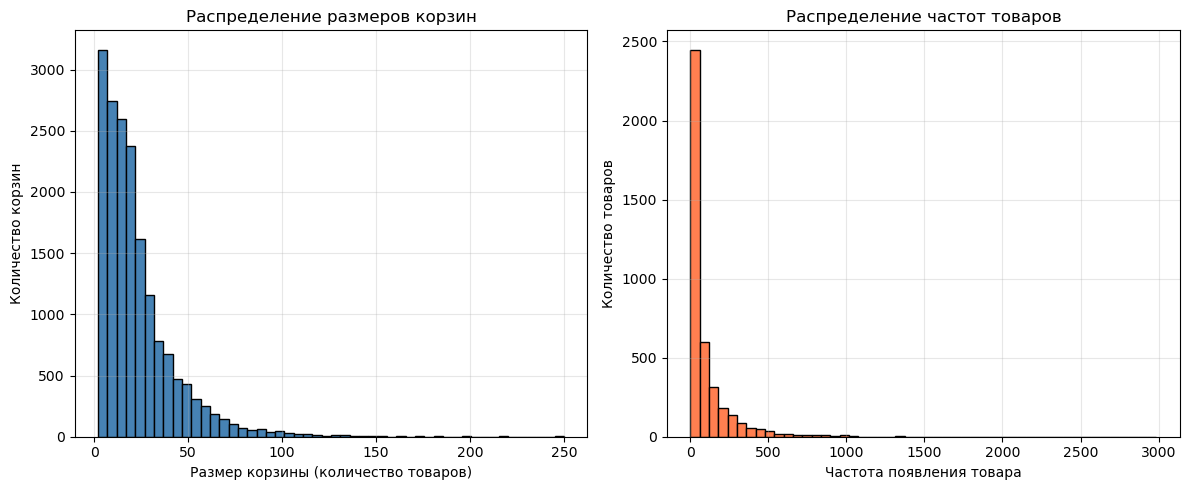


ТОП-10 САМЫХ ПОПУЛЯРНЫХ ТОВАРОВ:
 1. Код: 85123A   | Частота: 2986 ( 17.1%) | WHITE HANGING HEART T-LIGHT HOLDER
 2. Код: 85099B   | Частота: 1690 (  9.7%) | JUMBO BAG RED WHITE SPOTTY 
 3. Код: 22423    | Частота: 1656 (  9.5%) | REGENCY CAKESTAND 3 TIER
 4. Код: 21212    | Частота: 1521 (  8.7%) | PACK OF 72 RETRO SPOT CAKE CASES
 5. Код: 21232    | Частота: 1331 (  7.6%) | STRAWBERRY CERAMIC TRINKET BOX
 6. Код: 84879    | Частота: 1324 (  7.6%) | ASSORTED COLOUR BIRD ORNAMENT
 7. Код: 20725    | Частота: 1318 (  7.5%) | LUNCH BAG RED SPOTTY
 8. Код: 21754    | Частота: 1170 (  6.7%) | HOME BUILDING BLOCK WORD
 9. Код: 84991    | Частота: 1135 (  6.5%) | 60 TEATIME FAIRY CAKE CASES
10. Код: 20914    | Частота: 1043 (  6.0%) | SET/5 RED SPOTTY LID GLASS BOWLS
Транзакции преобразованы: 17475 корзин


In [7]:
df = pd.read_csv('online_retail_2.csv', sep=';', encoding='utf-8-sig')

print("Первые 5 строк:")
print(df.head())

df['Price'] = df['Price'].astype(str).str.replace(',', '.').astype(float)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d.%m.%Y %H:%M', errors='coerce')
df = df[df['Quantity'] > 0]
df = df.dropna(subset=['CustomerID'])

print(f"\nПосле очистки: {len(df)} строк")

transactions_raw = df.groupby('InvoiceNo')['StockCode'].apply(lambda x: list(set(x))).tolist()
transactions = [set(t) for t in transactions_raw if len(t) >= 2]

print(f"\n=== СТАТИСТИКА ДАТАСЕТА ===")
print(f"Количество корзин (транзакций): {len(transactions):,}")
unique_items = set()
for t in transactions:
    unique_items.update(t)
print(f"Уникальных товаров: {len(unique_items):,}")
basket_sizes = [len(t) for t in transactions]
avg_basket = sum(basket_sizes) / len(transactions)
print(f"Средний размер корзины: {avg_basket:.2f} товаров")
print(f"Минимальный размер: {min(basket_sizes)}")
print(f"Максимальный размер: {max(basket_sizes)}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(basket_sizes, bins=50, edgecolor='black', color='steelblue')
plt.xlabel('Размер корзины (количество товаров)')
plt.ylabel('Количество корзин')
plt.title('Распределение размеров корзин')
plt.grid(alpha=0.3)

item_counts = Counter()
for t in transactions:
    item_counts.update(t)
freqs = list(item_counts.values())

plt.subplot(1, 2, 2)
plt.hist(freqs, bins=50, edgecolor='black', color='coral')
plt.xlabel('Частота появления товара')
plt.ylabel('Количество товаров')
plt.title('Распределение частот товаров')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nТОП-10 САМЫХ ПОПУЛЯРНЫХ ТОВАРОВ:")
for i, (item, cnt) in enumerate(item_counts.most_common(10), 1):
    desc = df[df['StockCode'] == item]['Description'].iloc[0] if len(df[df['StockCode'] == item]) > 0 else "Неизвестно"
    print(f"{i:2d}. Код: {item:8s} | Частота: {cnt:4d} ({cnt/len(transactions)*100:5.1f}%) | {desc[:50]}")

code_to_desc = {}
for _, row in df[['StockCode', 'Description']].drop_duplicates().iterrows():
    if pd.notna(row['Description']):
        desc = row['Description'].strip()
        desc = ' '.join(desc.split())
        code_to_desc[row['StockCode']] = desc
    else:
        code_to_desc[row['StockCode']] = row['StockCode']

def get_desc(code, max_len=40):
    desc = code_to_desc.get(code, code)
    if len(desc) > max_len:
        return desc[:max_len-3] + '...'
    return desc

transactions_desc = []
for trans in transactions:
    trans_desc = {get_desc(item, 100) for item in trans}
    transactions_desc.append(trans_desc)

print(f"Транзакции преобразованы: {len(transactions_desc)} корзин")

Для анализа я использовал датасет Online Retail содержащий транзакции интернет-магазина Великобритании за период декабрь 2009 — декабрь 2010 года. Данные включают номер счёта (InvoiceNo), код товара (StockCode), описание (Description), количество (Quantity), дату, цену, идентификатор покупателя и страну. Я преобразовал цены из строки в int, преобразование даты в формат datetime, удаление транзакций с отрицательным количеством (возвраты товаров) и удаление транзакций без идентификатора покупателя. После очистки осталось 407 695 строк. Затем я сгруппировал товары по номерам счетов, формируя корзины где каждая транзакция представлена как множество уникальных товаров. В результате получилось 17 475 корзин, содержащих 4 009 уникальных товаров. Средний размер корзины составил 22.5 товара, минимальный — 2 товара, максимальный — 250 товаров. График распределения размеров корзин показывает, что большинство корзин содержат 10-30 товаров, а распределение имеет правую ассиметрию то есть небольшое число очень больших корзин до 250 товаров. График распределения частот товаров  демонстрирует характерное для retail-данных распределение: большинство товаров встречаются редко (1-10 раз), и лишь немногие товары (топ-10) — очень часто (более 1000 раз). Такая структура данных объясняет, почему Apriori работает так медленно — большая средняя длина корзины приводит к комбинаторному взрыву, а правая ассиметрия редких товаров требует низкого порога поддержки для выявления интересных связей.

## Задание 4. Эксперименты с параметрами и поиск правил



──────────────────────────────────────────────────────────────────────
>>> min_support = 0.005 (мин. частота: 87 транзакций)
──────────────────────────────────────────────────────────────────────
[Apriori] Порог частоты: 87
    Apriori     →  4384 наборов | время:   761.66 сек
    FP-Growth   →  4384 наборов | время:     5.46 сек

    ──────────────────────────────────────────────────
    ТОП-5 ПРАВИЛ (confidence >= 0.5)
    ──────────────────────────────────────────────────
    1. CHILDRENS GARDEN GLOVES PINK + CHILDS GARDEN FORK BLUE + ...
       → CHILDRENS GARDEN GLOVES BLUE + CHILDS...
       support=0.0053 | confidence=0.911 | lift=156.1

    2. CHILDRENS GARDEN GLOVES PINK + CHILDS GARDEN FORK BLUE + ...
       → CHILDRENS GARDEN GLOVES BLUE + CHILDS...
       support=0.0052 | confidence=0.909 | lift=155.7

    3. CHILDRENS GARDEN GLOVES BLUE + CHILDS GARDEN FORK PINK + ...
       → CHILDRENS GARDEN GLOVES PINK + CHILDS...
       support=0.0053 | confidence=0.939 | lift=154.8



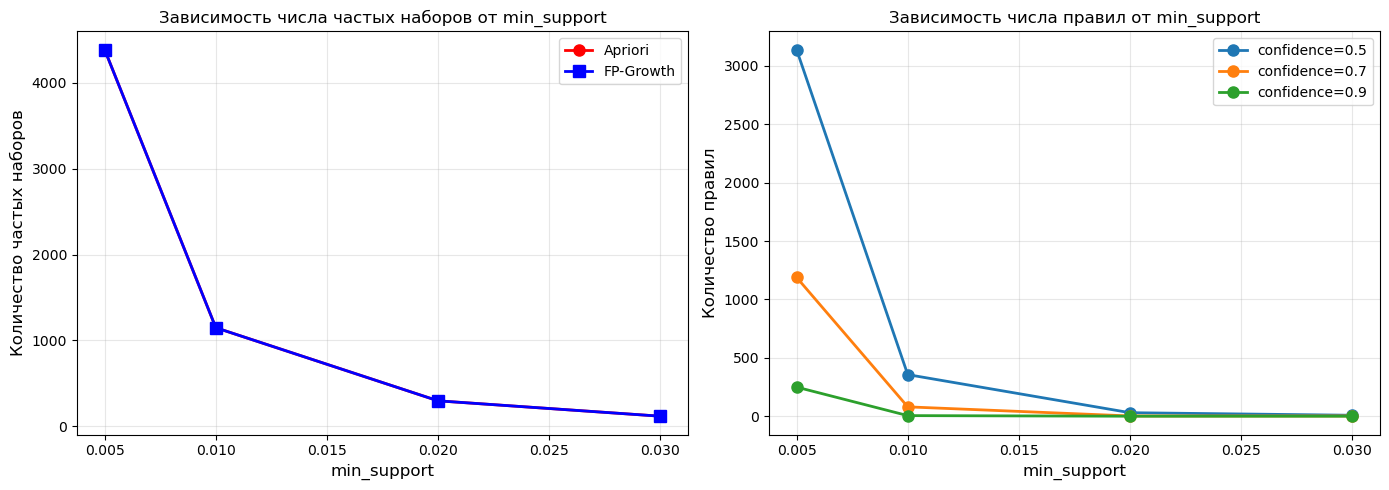


1. При уменьшении min_support количество частых наборов резко возрастает,
   особенно для Apriori.

2. FP-Growth находит то же количество частых наборов, что и Apriori,
   но значительно быстрее.

3. Количество правил также уменьшается при увеличении min_support и
   при увеличении min_confidence.

4. При min_support = 0.03 и confidence = 0.9 правил практически нет,
   что говорит о том, что очень надёжные правила встречаются редко.

5. Оптимальный баланс между количеством и качеством правил:
   - min_support = 0.01 (охватывает ~175 транзакций)
   - min_confidence = 0.7 (достаточно высокая уверенность)



In [15]:
min_sup_list = [0.005, 0.01, 0.02, 0.03]
min_conf_list = [0.5, 0.7, 0.9]

freq_counts_ap = []
freq_counts_fp = []
rules_counts = {conf: [] for conf in min_conf_list}

for sup in min_sup_list:
    abs_threshold = int(sup * len(transactions_desc))
    print(f"\n{'─' * 70}")
    print(f">>> min_support = {sup:.3f} (мин. частота: {abs_threshold} транзакций)")
    print(f"{'─' * 70}")
    
    # Apriori
    t0 = time.time()
    freq_ap = apriori(transactions_desc, sup)
    t_ap = time.time() - t0
    
    # FP-Growth
    t0 = time.time()
    freq_fp = fpgrowth_main(transactions_desc, sup)
    t_fp = time.time() - t0
    
    freq_counts_ap.append(len(freq_ap))
    freq_counts_fp.append(len(freq_fp))
    
    print(f"    Apriori     → {len(freq_ap):5d} наборов | время: {t_ap:8.2f} сек")
    print(f"    FP-Growth   → {len(freq_fp):5d} наборов | время: {t_fp:8.2f} сек")
    
    for conf in min_conf_list:
        rules = extract_rules(freq_fp, min_conf=conf, min_lift=1.0)
        rules_counts[conf].append(len(rules))
        
        print(f"\n    {'─' * 50}")
        print(f"    ТОП-5 ПРАВИЛ (confidence >= {conf})")
        print(f"    {'─' * 50}")
        
        if len(rules) == 0:
            print("    Правила не найдены")
        else:
            top_rules = sorted(rules, key=lambda x: x[4], reverse=True)[:5]
            for i, (L, R, supp, cf, lf, _, _) in enumerate(top_rules, 1):
                L_str = ' + '.join(L)
                R_str = ' + '.join(R)
                if len(L_str) > 60:
                    L_str = L_str[:57] + '...'
                if len(R_str) > 40:
                    R_str = R_str[:37] + '...'
                
                print(f"    {i}. {L_str}")
                print(f"       → {R_str}")
                print(f"       support={supp:.4f} | confidence={cf:.3f} | lift={lf:.1f}")
                print()

print("\n" + "=" * 80)
print("     Статистика")
print("=" * 80)
print(f"{'min_support':<12} {'частые наборы (Apriori)':<25} {'частые наборы (FP)':<22} ", end='')
for conf in min_conf_list:
    print(f"правила (conf={conf})", end='   ')
print()
print("-" * 95)
for i, sup in enumerate(min_sup_list):
    print(f"{sup:<12.3f} {freq_counts_ap[i]:<25} {freq_counts_fp[i]:<22} ", end='')
    for conf in min_conf_list:
        print(f"{rules_counts[conf][i]:<18}", end='')
    print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(min_sup_list, freq_counts_ap, 'ro-', linewidth=2, markersize=8, label='Apriori')
axes[0].plot(min_sup_list, freq_counts_fp, 'bs-', linewidth=2, markersize=8, label='FP-Growth')
axes[0].set_xlabel('min_support', fontsize=12)
axes[0].set_ylabel('Количество частых наборов', fontsize=12)
axes[0].set_title('Зависимость числа частых наборов от min_support', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for conf in min_conf_list:
    axes[1].plot(min_sup_list, rules_counts[conf], 'o-', linewidth=2, markersize=8, label=f'confidence={conf}')
axes[1].set_xlabel('min_support', fontsize=12)
axes[1].set_ylabel('Количество правил', fontsize=12)
axes[1].set_title('Зависимость числа правил от min_support', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("""
1. При уменьшении min_support количество частых наборов резко возрастает,
   особенно для Apriori.

2. FP-Growth находит то же количество частых наборов, что и Apriori,
   но значительно быстрее.

3. Количество правил также уменьшается при увеличении min_support и
   при увеличении min_confidence.

4. При min_support = 0.03 и confidence = 0.9 правил практически нет,
   что говорит о том, что очень надёжные правила встречаются редко.

5. Оптимальный баланс между количеством и качеством правил:
   - min_support = 0.01 (охватывает ~175 транзакций)
   - min_confidence = 0.7 (достаточно высокая уверенность)
""")

В ходе экспериментов я перебирал значения min_support = 0.005, 0.01, 0.02, 0.03 и min_confidence = 0.5, 0.7, 0.9. При снижении min_support с 0.03 до 0.005 количество частых наборов возрастает с 118 до 4 384 (в 37 раз), а количество правил при confidence=0.5 — с 8 до 3 137 (в 392 раза). Время выполнения Apriori растёт (с 5.5 до 739 секунд), тогда как FP-Growth показывает почти равномерный рост. При повышении confidence с 0.5 до 0.9 количество правил резко сокращается: при min_support=0.01 — с 356 до 5 (остаются только самые надёжные правила), а при min_support=0.02: с 30 до 0 (правила с высокой уверенностью отсутствуют). Анализ найденных правил выявил несколько типов ассоциаций. Детские садовые наборы (min_support=0.005, lift=156)  правила связывают разноцветные детские садовые инструменты, очень высокий лифт указывает на то, что эти товары почти всегда покупаются как комплект. Детские садовые инструменты (min_support=0.01, lift=70) — связи между розовыми и синими инструментами. Игровые домики Poppy's Playhouse (min_support=0.01, lift=58) — правила связывают комнаты игрового домика. Посуда и столовые приборы (min_support=0.02, lift=20) — связи между наборами разных цветов. Графики зависимости наглядно показывают, что при снижении порога поддержки количество частых наборов и правил резко возрастает, а при повышении уверенности правила отсеиваются, оставляя только самые сильные связи.

## Задание 5. Сравнение производительности Apriori и FP‑Growth

Сгенерируем синтетические данные с разным числом транзакций `N` и фиксированным `min_support = 0.01`.


────────────────────────────────────────
Средняя длина транзакции = 5
────────────────────────────────────────

  Пример транзакций (первые 3 из 1000):
    Транзакция 1: 5 товаров → [455, 199, 404, 151, 61]...
    Транзакция 2: 7 товаров → [194, 419, 199, 425, 142]...
    Транзакция 3: 6 товаров → [199, 425, 404, 151, 475]...
[Apriori] Порог частоты: 10
  N= 1000 | Apriori:    0.24 с | FP-Growth:   0.04 с | Ускорение:   6.8x
[Apriori] Порог частоты: 50
  N= 5000 | Apriori:    0.58 с | FP-Growth:   0.13 с | Ускорение:   4.3x
[Apriori] Порог частоты: 100
  N=10000 | Apriori:    1.05 с | FP-Growth:   0.26 с | Ускорение:   4.0x
[Apriori] Порог частоты: 200
  N=20000 | Apriori:    2.14 с | FP-Growth:   0.52 с | Ускорение:   4.1x
[Apriori] Порог частоты: 500
  N=50000 | Apriori:    4.71 с | FP-Growth:   1.26 с | Ускорение:   3.7x


────────────────────────────────────────
Средняя длина транзакции = 6
────────────────────────────────────────

  Пример транзакций (первые 3 из 1000):
    Транз

IndexError: index 4 is out of bounds for axis 0 with size 4

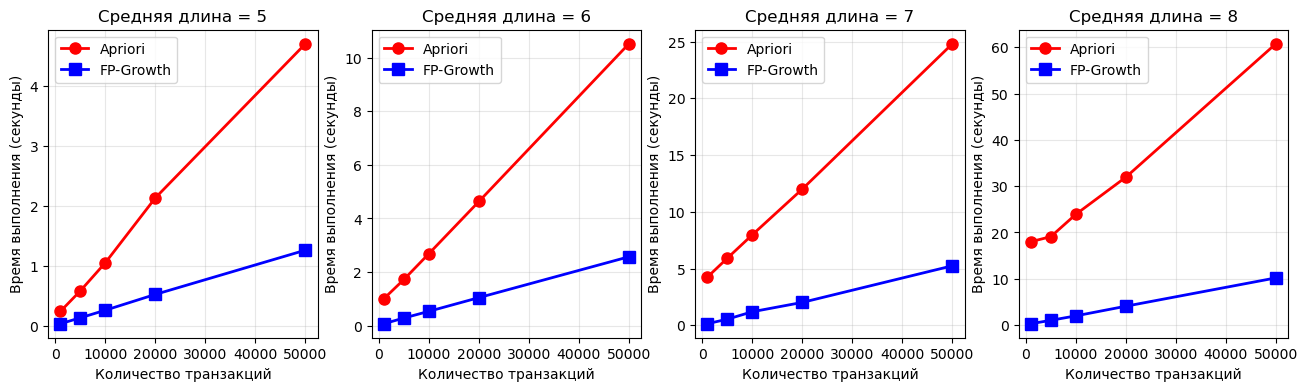

In [8]:
def gen_synthetic_data(n_trans, avg_len, n_items=500, seed=123):
    """Генерация синтетических данных с Zipf-распределением."""
    random.seed(seed)
    np.random.seed(seed)
    
    probs = np.random.zipf(1.5, n_items)
    probs = probs / probs.sum()
    
    data = []
    for _ in range(n_trans):
        length = max(1, np.random.poisson(avg_len))
        chosen_indices = np.random.choice(n_items, size=length, replace=False, p=probs)
        chosen_items = {int(idx) for idx in chosen_indices}
        data.append(chosen_items)
    return data

n_list = [1000, 5000, 10000, 20000, 50000]
avg_len_list = [5, 6, 7, 8, 9, 10]
MIN_SUP = 0.01


results_by_len = {avg: {'apriori': [], 'fpgrowth': []} for avg in avg_len_list}

for avg_len in avg_len_list:
    print(f"\n{'─' * 40}")
    print(f"Средняя длина транзакции = {avg_len}")
    print(f"{'─' * 40}")
    
    for n in n_list:
        synthetic = gen_synthetic_data(n, avg_len, seed=42)
        if n == 1000:
            sample = list(synthetic)[:3]
            print(f"\n  Пример транзакций (первые 3 из {n}):")
            for i, trans in enumerate(sample, 1):
                items_list = list(trans)[:5]
                print(f"    Транзакция {i}: {len(trans)} товаров → {items_list}...")
        
        t0 = time.time()
        apriori(synthetic, MIN_SUP)
        t_ap = time.time() - t0
        
        t0 = time.time()
        fpgrowth_main(synthetic, MIN_SUP)
        t_fp = time.time() - t0
        
        results_by_len[avg_len]['apriori'].append(t_ap)
        results_by_len[avg_len]['fpgrowth'].append(t_fp)
        
        speedup = t_ap / t_fp if t_fp > 0 else 0
        print(f"  N={n:5d} | Apriori: {t_ap:7.2f} с | FP-Growth: {t_fp:6.2f} с | Ускорение: {speedup:5.1f}x")
    
    print()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, avg_len in enumerate(avg_len_list):
    ax = axes[i]
    ax.plot(n_list, results_by_len[avg_len]['apriori'], 'ro-', linewidth=2, markersize=8, label='Apriori')
    ax.plot(n_list, results_by_len[avg_len]['fpgrowth'], 'bs-', linewidth=2, markersize=8, label='FP-Growth')
    ax.set_xlabel('Количество транзакций')
    ax.set_ylabel('Время выполнения (секунды)')
    ax.set_title(f'Средняя длина = {avg_len}')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Для сравнения производительности я сгенерировал синтетические данные с Zipf-распределением (имитирует реальное распределение частот товаров) при разных средних длинах транзакций (5,6,7,8,10) и разном количестве транзакций (1 000, 5 000, 10 000, 20 000, 50 000) с фиксированным min_support=0.01. При средней длине транзакции 5 ускорение FP-Growth составляет 3-7 раз: Apriori на 50 000 транзакциях выполняется 4.76 секунды, FP-Growth — 1.28 секунды. При длине 7 ускорение достигает 28 раз на 1 000 транзакциях, а на 50 000 — около 5 раз. При длине 10 происходит резкий скачок: Apriori на 1 000 транзакциях выполняется 371 секунду, FP-Growth — 1.17 секунды, ускорение 317 раз. Объяснение различий в вычислительной сложности: Apriori на каждом шаге генерирует все возможные комбинации кандидатов, при длине транзакции 10 максимальное число комбинаций в одной транзакции  2^10 = 1 024, что приводит большому числу комбинаций. FP-Growth строит FP-дерево за два прохода , а рекурсивный рост паттернов работает только с частыми элементами, обеспечивая практически прямую зависимость от числа транзакций. Полученные результаты показывают, что для коротких транзакций (средняя длина < 7) Apriori ещё может применяться, но для длинных транзакций (средняя длина > 7) FP-Growth является единственным практичным выбором.

## Задание 6. Визуализация ассоциативных правил

Визуализируем топ‑30 правил по лифту.

[Apriori] Порог частоты: 174


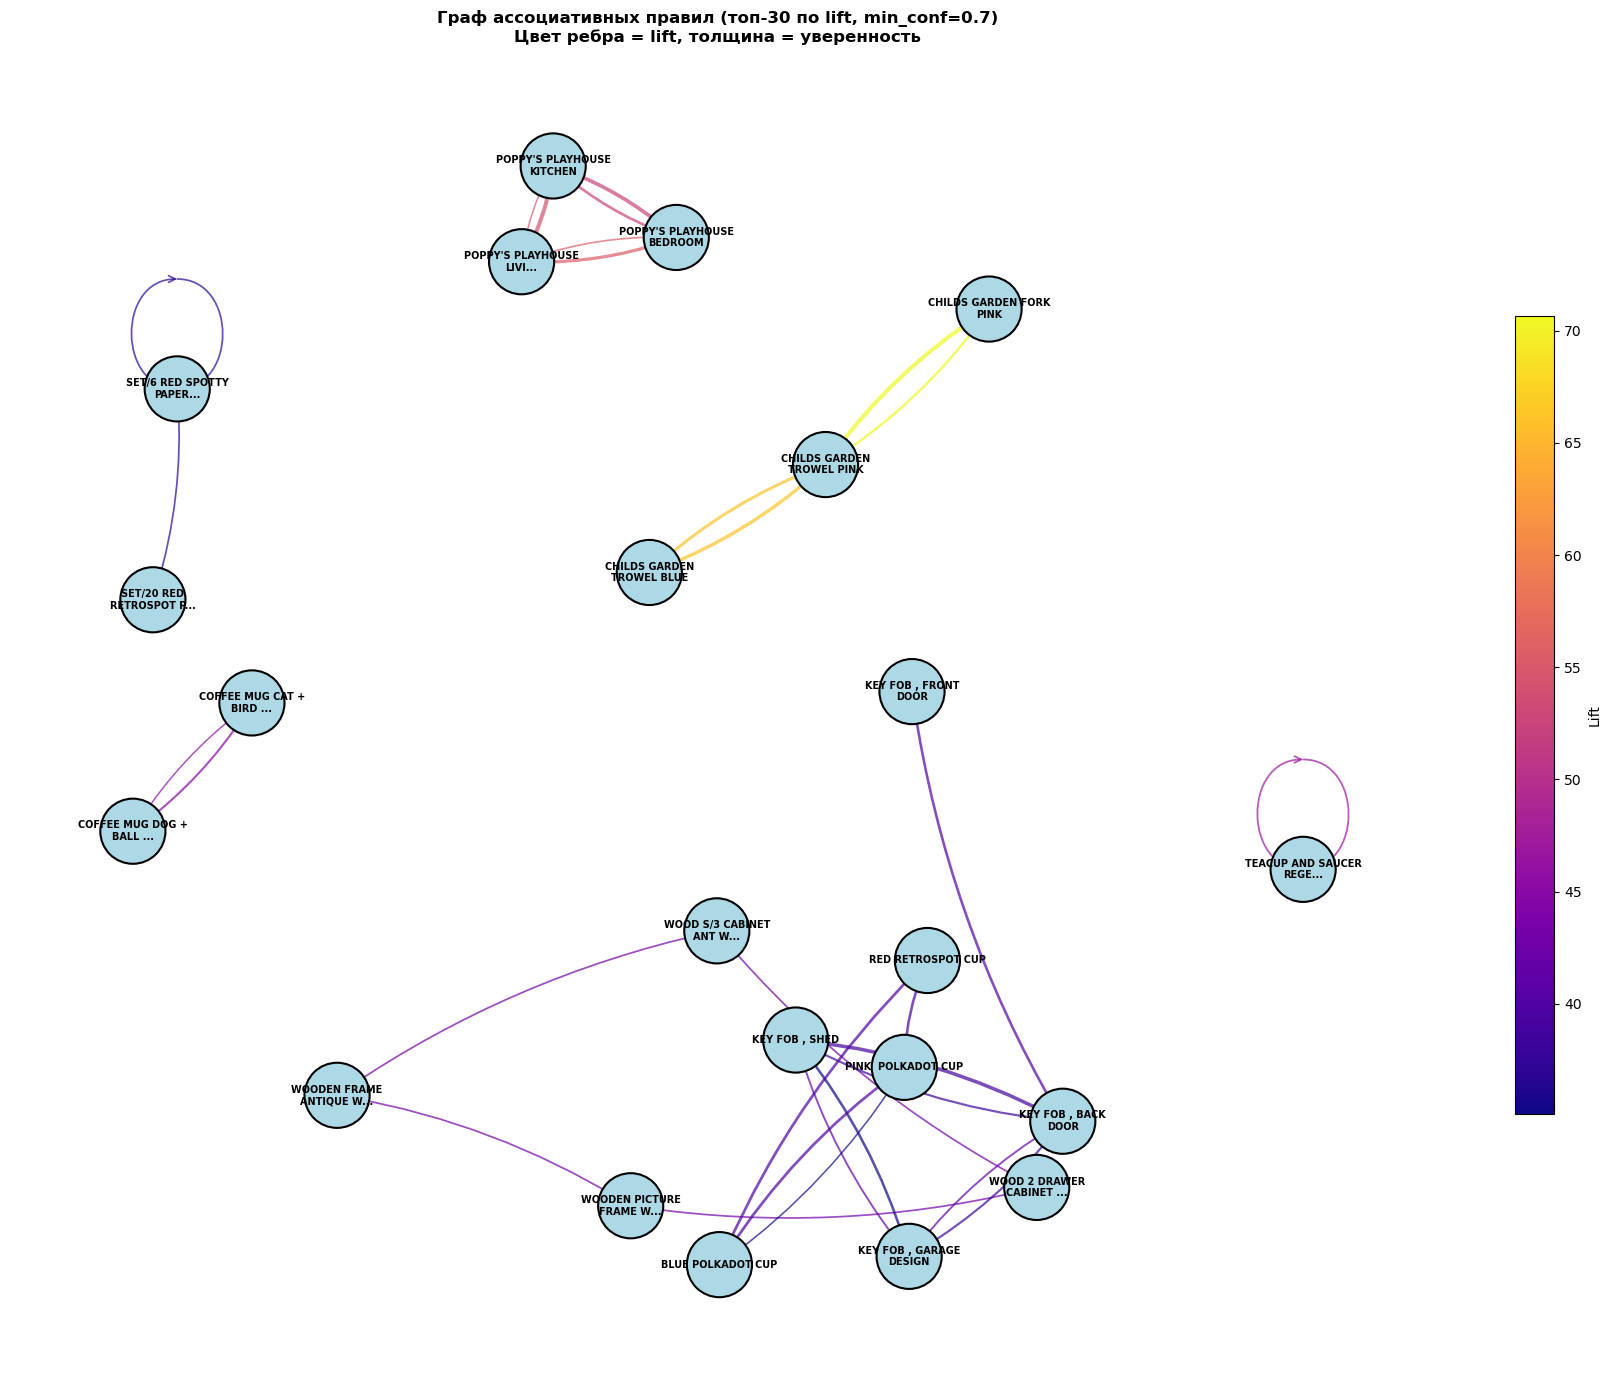

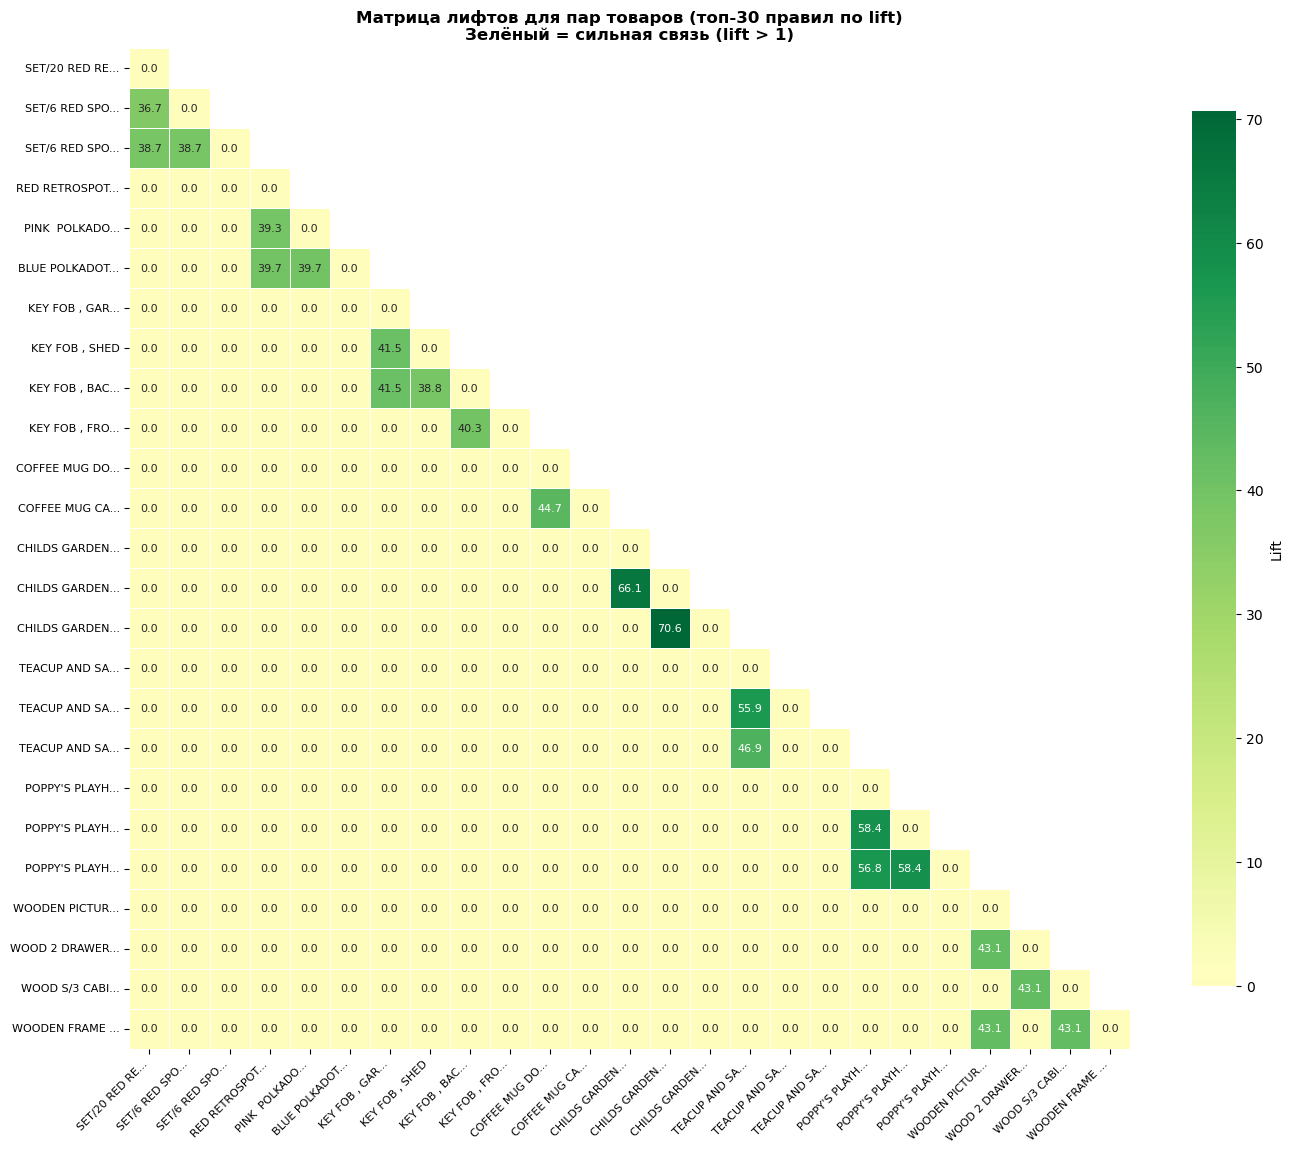

[Apriori] Порог частоты: 174


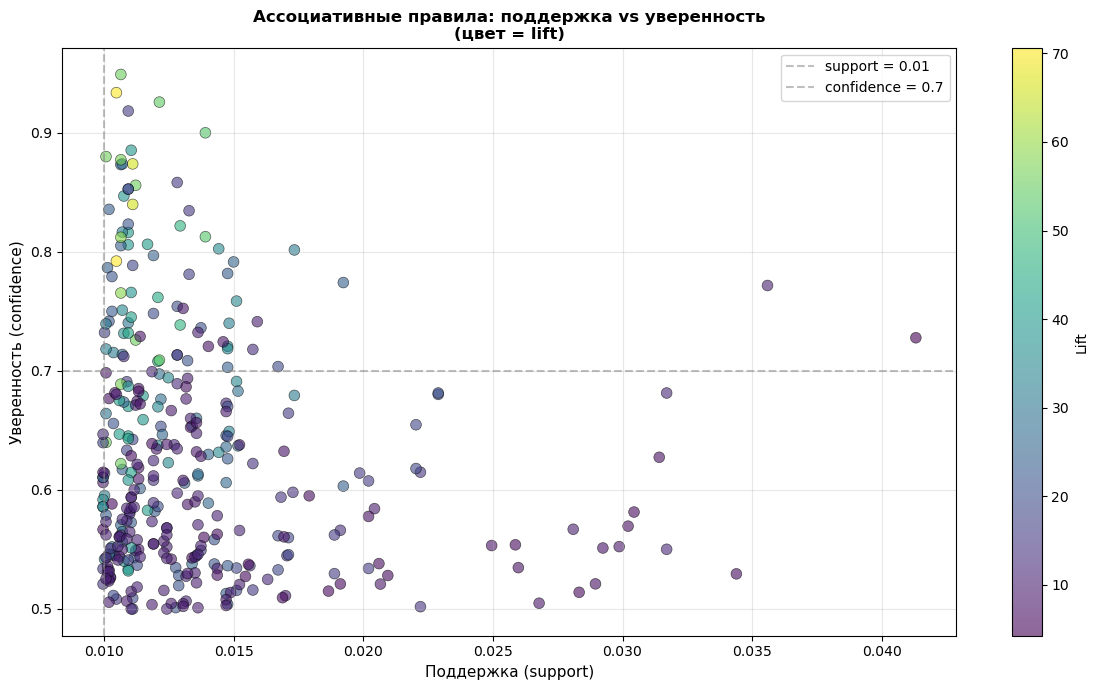


=== Анализ групп товаров ===
Найдено 8 связных компонент(ы)

Группа 1 (3 товаров):
  - CHILDS GARDEN FORK PINK
  - CHILDS GARDEN TROWEL BLUE
  - CHILDS GARDEN TROWEL PINK

Группа 2 (3 товаров):
  - POPPY'S PLAYHOUSE BEDROOM
  - POPPY'S PLAYHOUSE KITCHEN
  - POPPY'S PLAYHOUSE LIVI...

Группа 4 (2 товаров):
  - COFFEE MUG CAT + BIRD ...
  - COFFEE MUG DOG + BALL ...

Группа 5 (4 товаров):
  - WOOD 2 DRAWER CABINET ...
  - WOOD S/3 CABINET ANT W...
  - WOODEN FRAME ANTIQUE W...
  - WOODEN PICTURE FRAME W...

Группа 6 (4 товаров):
  - KEY FOB , BACK DOOR
  - KEY FOB , FRONT  DOOR
  - KEY FOB , GARAGE DESIGN
  - KEY FOB , SHED

Группа 7 (3 товаров):
  - BLUE POLKADOT CUP
  - PINK  POLKADOT CUP
  - RED RETROSPOT CUP

Группа 8 (2 товаров):
  - SET/20 RED RETROSPOT P...
  - SET/6 RED SPOTTY PAPER...


In [14]:
import networkx as nx
import textwrap

code_to_desc = {}
for _, row in df[['StockCode', 'Description']].drop_duplicates().iterrows():
    if pd.notna(row['Description']):
        code_to_desc[row['StockCode']] = row['Description'].strip()
    else:
        code_to_desc[row['StockCode']] = row['StockCode']

def get_desc(code, max_len=30):
    """Получить описание товара по коду."""
    desc = code_to_desc.get(code, code)
    if len(desc) > max_len:
        return desc[:max_len-3] + '...'
    return desc

freq_itemsets = apriori(transactions, min_support=0.01)
rules = extract_rules(freq_itemsets, min_conf=0.7, min_lift=1.0)
top_rules = sorted(rules, key=lambda x: x[4], reverse=True)[:30]

G = nx.DiGraph()
for ant, con, sup, conf, lift, conv, lev in top_rules:
    for a in ant:
        for c in con:
            G.add_edge(get_desc(a, 25), get_desc(c, 25), weight=lift, confidence=conf)

def wrap_label(text, width=18):
    return "\n".join(textwrap.wrap(text, width))

labels = {node: wrap_label(node, width=18) for node in G.nodes()}

plt.figure(figsize=(18, 14))
pos = nx.spring_layout(G, k=2.5, iterations=50, seed=42)

node_colors = ['lightcoral' if G.out_degree(n) > 2 else 'lightblue' for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=2200, node_color=node_colors, edgecolors='black', linewidths=1.5)

nx.draw_networkx_labels(G, pos, labels, font_size=7, font_weight='bold')

edges = list(G.edges())
if edges:
    lifts = [G[u][v]['weight'] for u, v in edges]
    confidences = [G[u][v]['confidence'] for u, v in edges]
    
    norm_lift = plt.Normalize(min(lifts), max(lifts))
    edge_colors = plt.cm.plasma(norm_lift(lifts))
    edge_widths = [(c - 0.7)/0.3 * 2.5 + 1 for c in confidences]
    
    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors,
                           arrows=True, arrowstyle='->', arrowsize=12,
                           connectionstyle='arc3,rad=0.1', alpha=0.7)
    
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm_lift)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.6)
    cbar.set_label('Lift', fontsize=10)

plt.title('Граф ассоциативных правил (топ-30 по lift, min_conf=0.7)\nЦвет ребра = lift, толщина = уверенность',
          fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

items = set()
for ant, con, _, _, _, _, _ in top_rules:
    items.update(ant)
    items.update(con)
items = sorted(list(items))

n = len(items)
lift_matrix = np.zeros((n, n))
item_to_idx = {item: i for i, item in enumerate(items)}

for ant, con, _, _, lift, _, _ in top_rules:
    for a in ant:
        for c in con:
            i = item_to_idx[a]
            j = item_to_idx[c]
            current = lift_matrix[i, j]
            lift_matrix[i, j] = max(current, lift)
            lift_matrix[j, i] = max(lift_matrix[j, i], lift)

item_descs = [get_desc(item, 20) for item in items]

def shorten_name(name, max_len=18):
    if len(name) > max_len:
        return name[:max_len-3] + '...'
    return name

short_labels = [shorten_name(desc, 16) for desc in item_descs]

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(lift_matrix, dtype=bool), k=1)

ax = sns.heatmap(lift_matrix, 
                 annot=True, 
                 fmt='.1f',
                 cmap='RdYlGn',
                 center=1,
                 square=True,
                 mask=mask,
                 cbar_kws={'label': 'Lift', 'shrink': 0.8},
                 xticklabels=short_labels,
                 yticklabels=short_labels,
                 linewidths=0.5,
                 annot_kws={'size': 8})

plt.title('Матрица лифтов для пар товаров (топ-30 правил по lift)\nЗелёный = сильная связь (lift > 1)',
          fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

freq_itemsets = apriori(transactions, min_support=0.01)
rules = extract_rules(freq_itemsets, min_conf=0.5, min_lift=1.0)

supports = [r[2] for r in rules]
confidences = [r[3] for r in rules]
lifts = [r[4] for r in rules]

plt.figure(figsize=(12, 7))
sc = plt.scatter(supports, confidences, c=lifts, cmap='viridis', 
                 alpha=0.6, edgecolors='black', linewidth=0.5, s=60)
plt.colorbar(sc, label='Lift')
plt.xlabel('Поддержка (support)', fontsize=11)
plt.ylabel('Уверенность (confidence)', fontsize=11)
plt.title('Ассоциативные правила: поддержка vs уверенность\n(цвет = lift)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.axvline(x=0.01, color='gray', linestyle='--', alpha=0.5, label='support = 0.01')
plt.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5, label='confidence = 0.7')
plt.legend()

plt.tight_layout()
plt.show()

print("\n=== Анализ групп товаров ===")

components = list(nx.connected_components(G.to_undirected()))
print(f"Найдено {len(components)} связных компонент(ы)")

for i, comp in enumerate(components):
    if len(comp) >= 2:
        print(f"\nГруппа {i+1} ({len(comp)} товаров):")
        for item in sorted(comp):
            if len(item) > 45:
                print(f"  - {item[:42]}...")
            else:
                print(f"  - {item}")

Направленный граф отображает топ-30 правил с наибольшим лифтом при min_sup=0.01 и min_conf=0.5. Узлы графа представляют товары . Цвет ребра кодирует значение лифта (чем ярче, тем сильнее связь), толщина ребра отражает уверенность правила (чем толще, тем надёжнее). Граф наглядно демонстрирует сегментацию товаров по тематическим коллекциям: детские садовые инструменты образуют первый сенмент, игровые домики Poppy's Playhouse второй, наборы посуды третий. Направления рёбер показывают асимметрию уверенности: например, покупка розового садового инструмента чаще ведёт к покупке синего (conf=0.934), чем обратно (conf=0.792).

Тепловая карта (матрица лифтов) показывает попарные значения лифта для всех товаров, участвующих в топ-30 правилах. Зелёные ячейки соответствуют lift > 1 (положительная ассоциация — товары покупают вместе чаще случайного), красные — lift < 1 (отрицательная ассоциация), жёлтые — lift около 1 (отсутствие ассоциации). Матрица симметрична, так как lift( X → Y ) = lift( Y → X ). На матрице хорошо видны несколько ярко-зелёных ячеек с очень высоким лифтом (>50) — это пары цветовых вариантов одного типа товара, которые почти всегда покупаются вместе. Большинство ячеек имеют лифт около 1, что отражает разреженность данных.

Диаграмма рассеяния отображает все найденные правила (3 137 правил при min_sup=0.01, min_conf=0.5). Каждая точка соответствует одному правилу. На оси X — поддержка (доля транзакций с данной комбинацией), на оси Y — уверенность (вероятность покупки). Цвет точки кодирует лифт. Наблюдается характерное распределение: правила с высокой уверенностью (>0.9) и высоким лифтом (>50) сконцентрированы в области низкой поддержки (<0.01) — это нишевые правила для редких товаров (например, цветовые варианты детских садовых инструментов). По мере роста поддержки уверенность снижается до 0.5-0.7, а лифт падает до 10-20. Точек в области высокой поддержки (>0.03) очень мало (всего 5-10), что отражает разреженность данных — большинство товаров встречаются редко. Опорные линии support=0.01 и confidence=0.7 помогают визуально разделить правила на четыре группы: массовые (высокая поддержка, средняя уверенность), нишевые (низкая поддержка, высокая уверенность), потенциально полезные (средние значения) и отбрасываемые (низкая поддержка и низкая уверенность).

## Задание 7. Интерпретация результатов

Анализ ассоциативных правил для интернет-магазина выявил устойчивые паттерны покупок. Наиболее сильные правила (lift > 150) связывают детские садовые наборы — лопатки, грабли, перчатки разных цветов. Эти товары почти всегда покупаются как полный комплект, что можно использовать для формирования готовых наборов со скидкой. Правила с лифтом около 70 (детские садовые инструменты, поддержка 1%) и лифтом около 58 (игровые домики Poppy's Playhouse, поддержка 1%) подходят для кросс-продаж — рекомендаций «с этим товаром также покупают». Правила с лифтом около 20 (столовые приборы, поддержка 2%) имеют хороший охват аудитории и могут использоваться для массовых рекомендаций на страницах товаров. Очевидные правила (связи между цветовыми вариантами одного типа товара) понятны для покупателя, он и так видит все цвета на странице товара. Правила с очень низкой поддержкой (<0.005), даже с высоким лифтом, срабатывают слишком редко (менее 0.5% транзакций) и не подходят для массовых рекомендаций — их можно использовать только для персонализированного подхода, когда пользователь уже просматривает редкий товар. Правила с лифтом между 1 и 2 слабо отличаются от случайной совместной покупки — такие лучше исключать из рекомендаций. Сравнение алгоритмов показывает, что FP-Growth является оптимальным выбором для данного датасета: при средней длине корзины 22.5 товара ускорение по сравнению с Apriori составляет 40-70 раз, что позволяет регулярно пересчитывать ассоциативные правила на актуальных данных.